<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  3.73MB/s    in 39s     

2026-10-07 14:29:02 (3.91 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



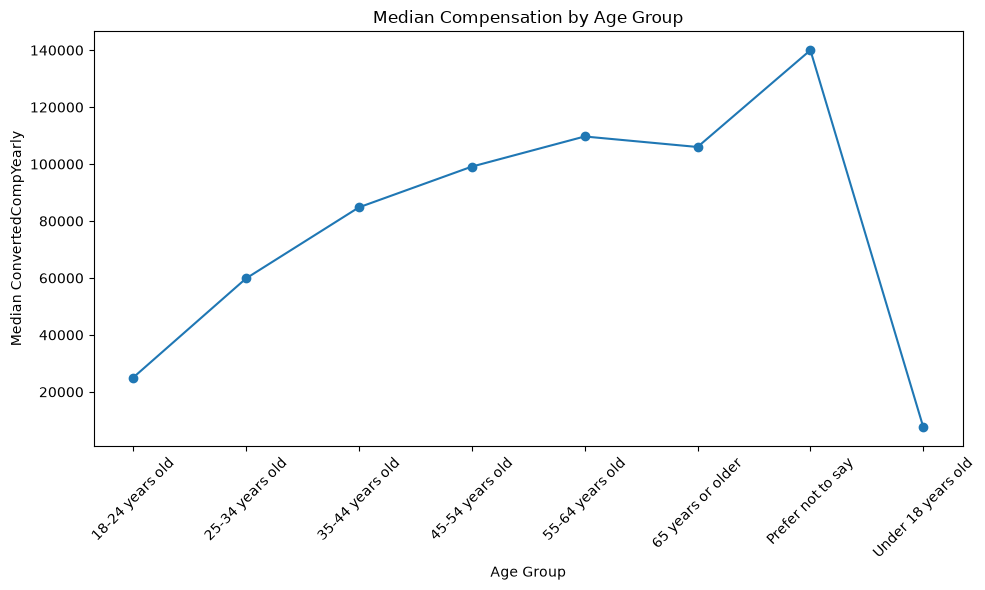

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Create database connection
conn = sqlite3.connect("survey-data.sqlite")

QUERY = """
SELECT Age, ConvertedCompYearly
FROM main
WHERE ConvertedCompYearly IS NOT NULL
"""

df_comp = pd.read_sql_query(QUERY, conn)

median_comp = df_comp.groupby('Age')['ConvertedCompYearly'].median()

plt.figure(figsize=(10,6))

plt.plot(
    median_comp.index,
    median_comp.values,
    marker='o'
)

plt.title('Median Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



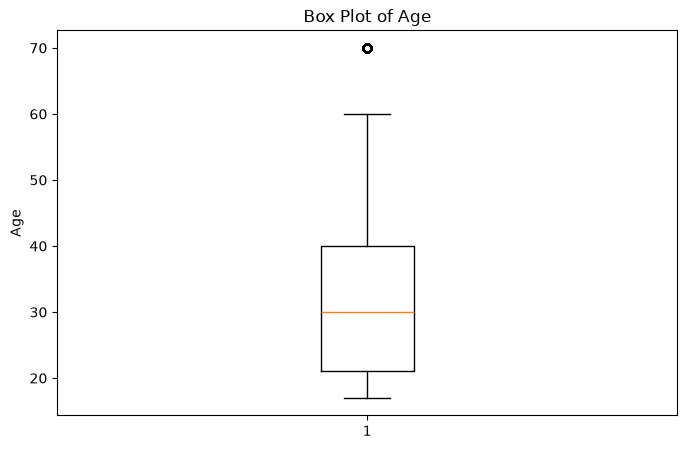

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""

df_age = pd.read_sql_query(QUERY, conn)

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None
}

df_age['Age_numeric'] = df_age['Age'].map(age_mapping)

plt.figure(figsize=(8,5))

plt.boxplot(df_age['Age_numeric'].dropna())

plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



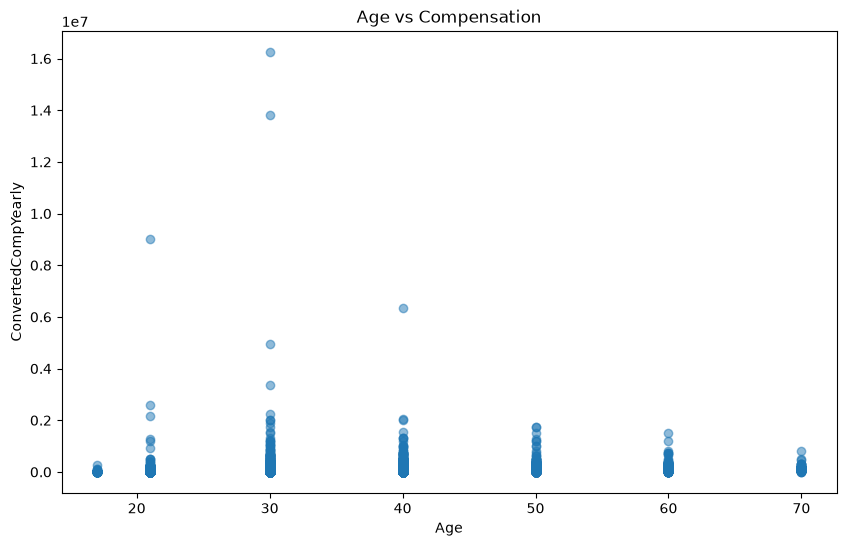

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df_scatter['Age_numeric'],
    df_scatter['ConvertedCompYearly'],
    alpha=0.5
)

plt.title('Age vs Compensation')
plt.xlabel('Age')
plt.ylabel('ConvertedCompYearly')

plt.show()


##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


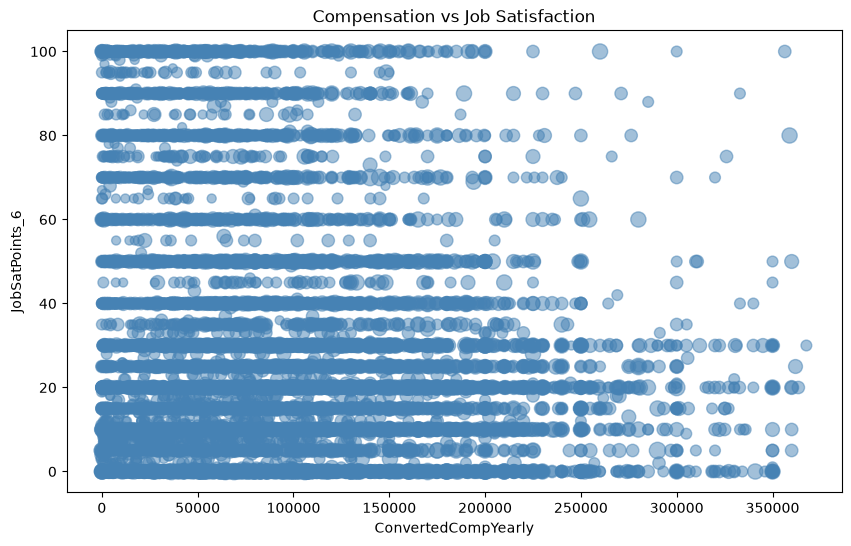

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

QUERY = """
SELECT Age,
       ConvertedCompYearly,
       JobSatPoints_6
FROM main
WHERE Age IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_bubble = pd.read_sql_query(QUERY, conn)

# Convert Age to numeric
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None
}

df_bubble['Age_numeric'] = df_bubble['Age'].map(age_mapping)

# Remove null age values
df_bubble = df_bubble.dropna(subset=['Age_numeric'])

# Remove extreme compensation outliers
upper_limit = df_bubble['ConvertedCompYearly'].quantile(0.99)

df_bubble = df_bubble[
    df_bubble['ConvertedCompYearly'] <= upper_limit
]

plt.figure(figsize=(10,6))

plt.scatter(
    df_bubble['ConvertedCompYearly'],
    df_bubble['JobSatPoints_6'],
    s=df_bubble['Age_numeric'] * 2,
    alpha=0.5,
    color='steelblue'
)

plt.title('Compensation vs Job Satisfaction')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('JobSatPoints_6')

plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



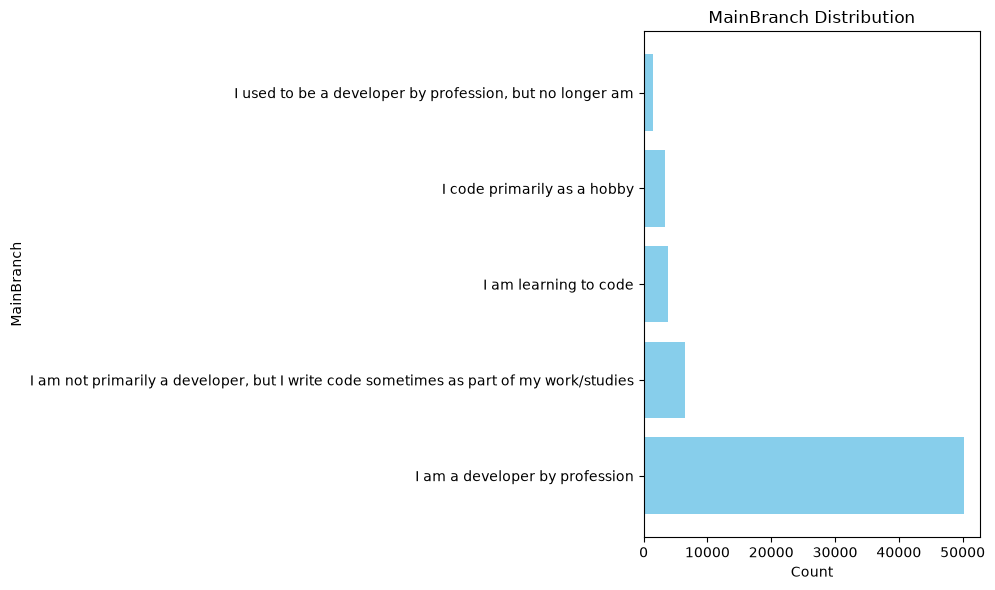

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

QUERY = """
SELECT MainBranch
FROM main
WHERE MainBranch IS NOT NULL
"""

df_branch = pd.read_sql_query(QUERY, conn)

branch_counts = df_branch['MainBranch'].value_counts()

plt.figure(figsize=(10,6))

plt.barh(
    branch_counts.index,
    branch_counts.values,
    color='skyblue'
)

plt.title('MainBranch Distribution')
plt.xlabel('Count')
plt.ylabel('MainBranch')

plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



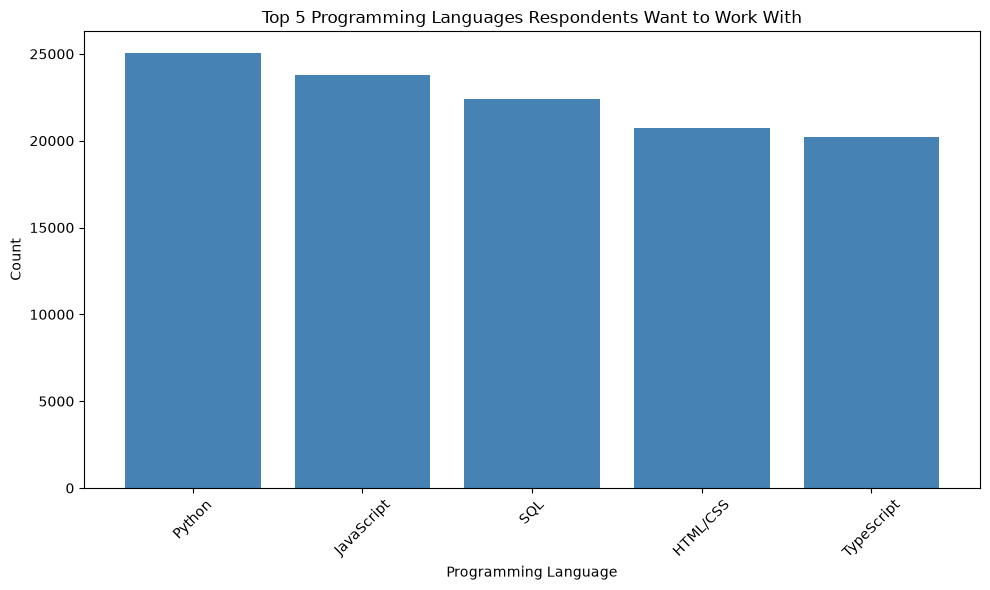

In [18]:
from collections import Counter
import matplotlib.pyplot as plt

QUERY = """
SELECT LanguageWantToWorkWith
FROM main
WHERE LanguageWantToWorkWith IS NOT NULL
"""

df_lang = pd.read_sql_query(QUERY, conn)

languages = []

for item in df_lang['LanguageWantToWorkWith']:
    languages.extend(str(item).split(';'))

top5 = Counter(languages).most_common(5)

lang_names = [x[0].strip() for x in top5]
lang_counts = [x[1] for x in top5]

plt.figure(figsize=(10,6))

plt.bar(
    lang_names,
    lang_counts,
    color='steelblue'
)

plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


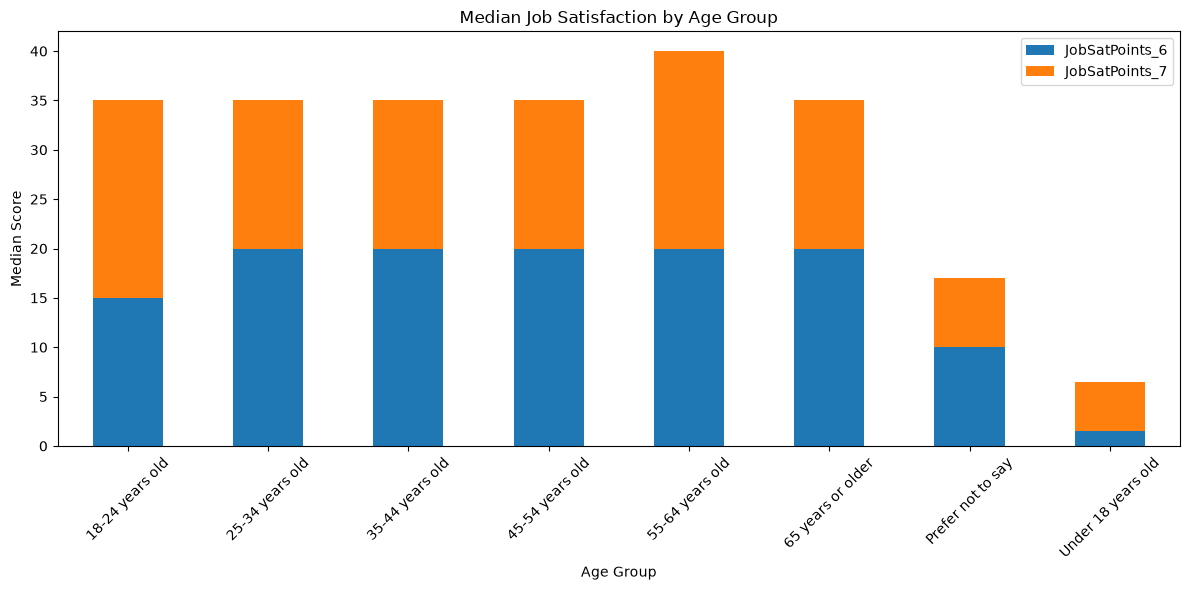

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

QUERY = """
SELECT Age,
       JobSatPoints_6,
       JobSatPoints_7
FROM main
WHERE JobSatPoints_6 IS NOT NULL
AND JobSatPoints_7 IS NOT NULL
"""

df_jobsat = pd.read_sql_query(QUERY, conn)

age_stats = df_jobsat.groupby('Age')[
    ['JobSatPoints_6', 'JobSatPoints_7']
].median()

age_stats.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Median Job Satisfaction by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



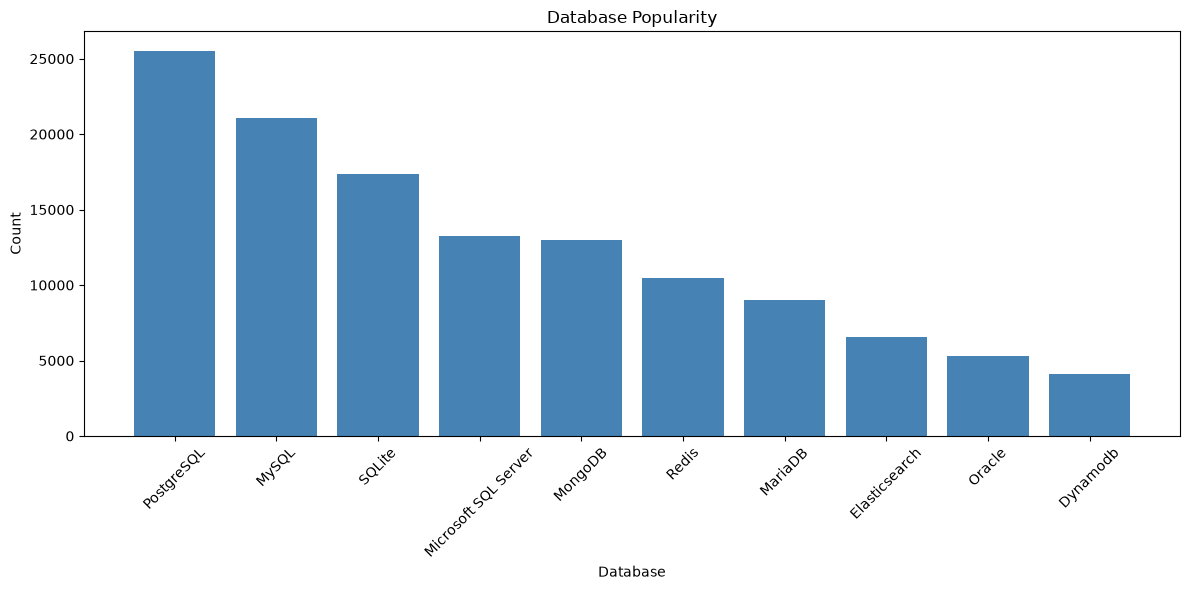

In [21]:
from collections import Counter

QUERY = """
SELECT DatabaseHaveWorkedWith
FROM main
WHERE DatabaseHaveWorkedWith IS NOT NULL
"""

df_db = pd.read_sql_query(QUERY, conn)

databases = []

for item in df_db['DatabaseHaveWorkedWith']:
    databases.extend(str(item).split(';'))

top10 = Counter(databases).most_common(10)

db_names = [x[0].strip() for x in top10]
db_counts = [x[1] for x in top10]

plt.figure(figsize=(12,6))

plt.bar(
    db_names,
    db_counts,
    color='steelblue'
)

plt.title('Database Popularity')
plt.xlabel('Database')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



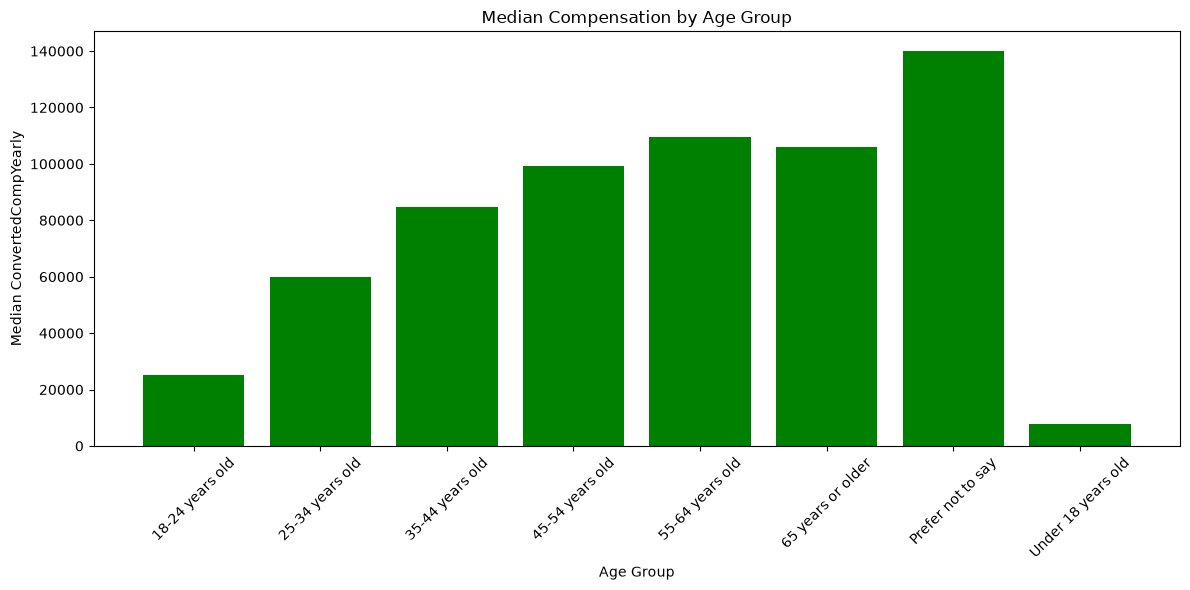

In [23]:
QUERY = """
SELECT Age,
       ConvertedCompYearly
FROM main
WHERE ConvertedCompYearly IS NOT NULL
"""

df_comp = pd.read_sql_query(QUERY, conn)

median_comp = (
    df_comp
    .groupby('Age')['ConvertedCompYearly']
    .median()
)

plt.figure(figsize=(12,6))

plt.bar(
    median_comp.index,
    median_comp.values,
    color='green'
)

plt.title('Median Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



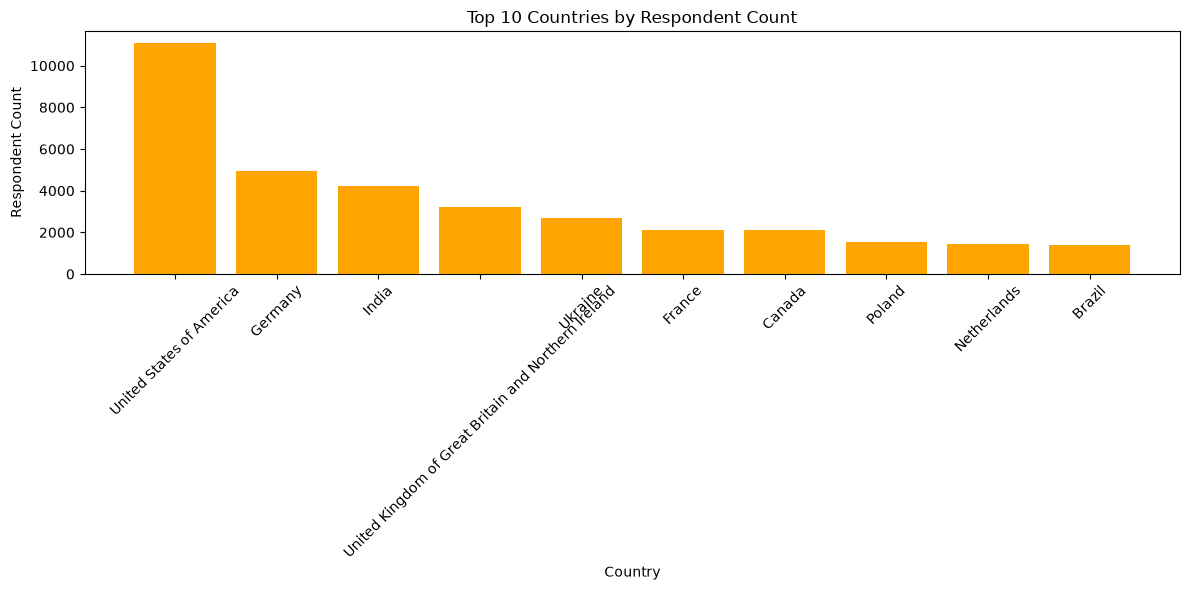

In [24]:
QUERY = """
SELECT Country
FROM main
WHERE Country IS NOT NULL
"""

df_country = pd.read_sql_query(QUERY, conn)

top_countries = df_country['Country'].value_counts().head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_countries.index,
    top_countries.values,
    color='orange'
)

plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Country')
plt.ylabel('Respondent Count')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
